# 交差検証

[ch9_3_Statistical_Model_Metrics.ipynb](https://github.com/ghmagazine/python_anomaly_detection_book/blob/main/notebooks/ch9_3_Statistical_Model_Metrics.ipynb)で解説したAICやBIC、WAICは、学習データだけを用いて「モデルが未知データをどれだけ説明できるか」を推定する指標でした。

これに対し、学習データの代わりに未知データを模したテストデータを適切に分割して指標算出に用いれば、「推定」ではなく実際に未知データに対する性能、すなわち汎化性能を精度よく求めることができます。
このようなテストデータを用いた評価では、分割によるデータ数が減少するため、限られたデータを効率よく利用することが重要です。このような高効率なデータ利用を実現するため、学習データとテストを入れ替えて複数回評価を実施する方法を、**交差検証**（cross-validation）と呼びます。

書籍では異常検知の性能評価手法を⼤きく、「**1.ラベルの予測精度**」、「**2.統計モデル選択の妥当性**」に分けましたが、交差検証を実施する場合はそれぞれ以下の指標を使用できます。

1. ラベルの予測精度：目的に合わせて任意の指標を使用できる（ただし異常データが少ない場合は、分割によるデータ数減少での指標信頼性低下に注意）
2. 統計モデル選択の妥当性：対数尤度を用いる（後述するように、AICやBIC、WAICを用いるのは不適切）

### ホールドアウト法と交差検証

学習・テストデータを分ける最も単純な方法は、以下の図に示すようにデータを2分割する方法です。この方法は**ホールドアウト法**（hold-out validation）と呼ばれます。

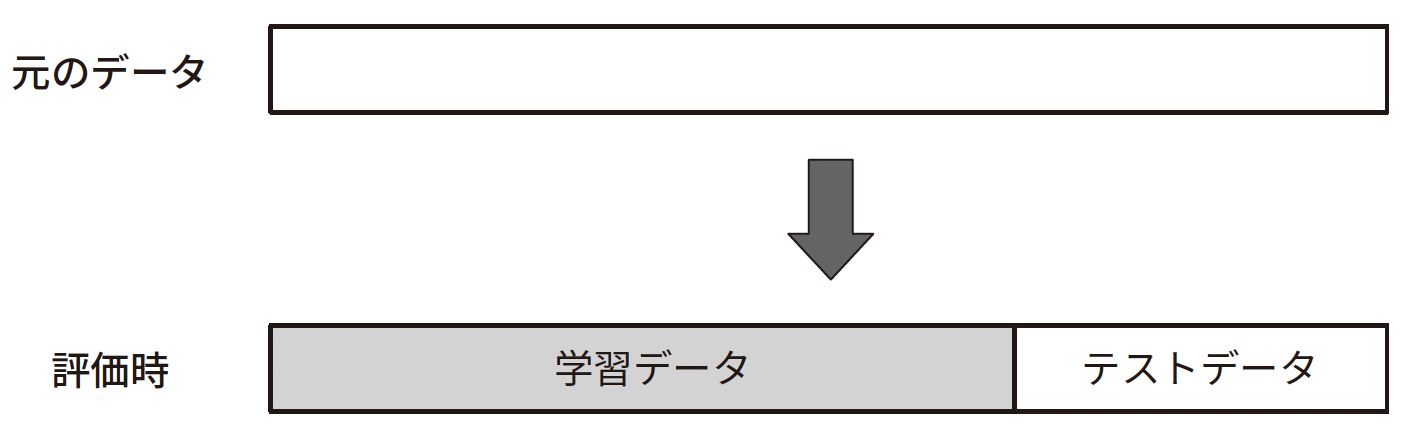

[ch9_3_Classification_Metrics.ipynb](https://github.com/ghmagazine/python_anomaly_detection_book/blob/main/notebooks/ch9_3_Classification_Metrics.ipynb)や[ch9_3_Statistical_Model_Metrics.ipynb](https://github.com/ghmagazine/python_anomaly_detection_book/blob/main/notebooks/ch9_3_Statistical_Model_Metrics.ipynb)（対数尤度のみ）でも、ホールドアウト法で性能を評価していました。この方法では分割した片方の学習データは学習のみに、もう片方のテストデータは指標算出（テスト）のみに利用されます。これでは元のデータ数と比べて、学習・テストそれぞれに利用できるデータ数は目減りしてしまいます。そこで1回目の学習・テストで使ったデータを入れ替えてもう一度評価を行えば、すべてのデータを学習とテストの両方に利用できます。この発想を一般化した方法が**交差検証**（cross-validation）です。

交差検証では、以下の図に示すように、評価を$K$回（図では$K = 5$）に分けた上で、データを互い違いに分割します。このおのおのの分割パターンでそれぞれ評価指標を求め、平均をとったもの（中央値等をとることもある）を最終的な評価指標とします。

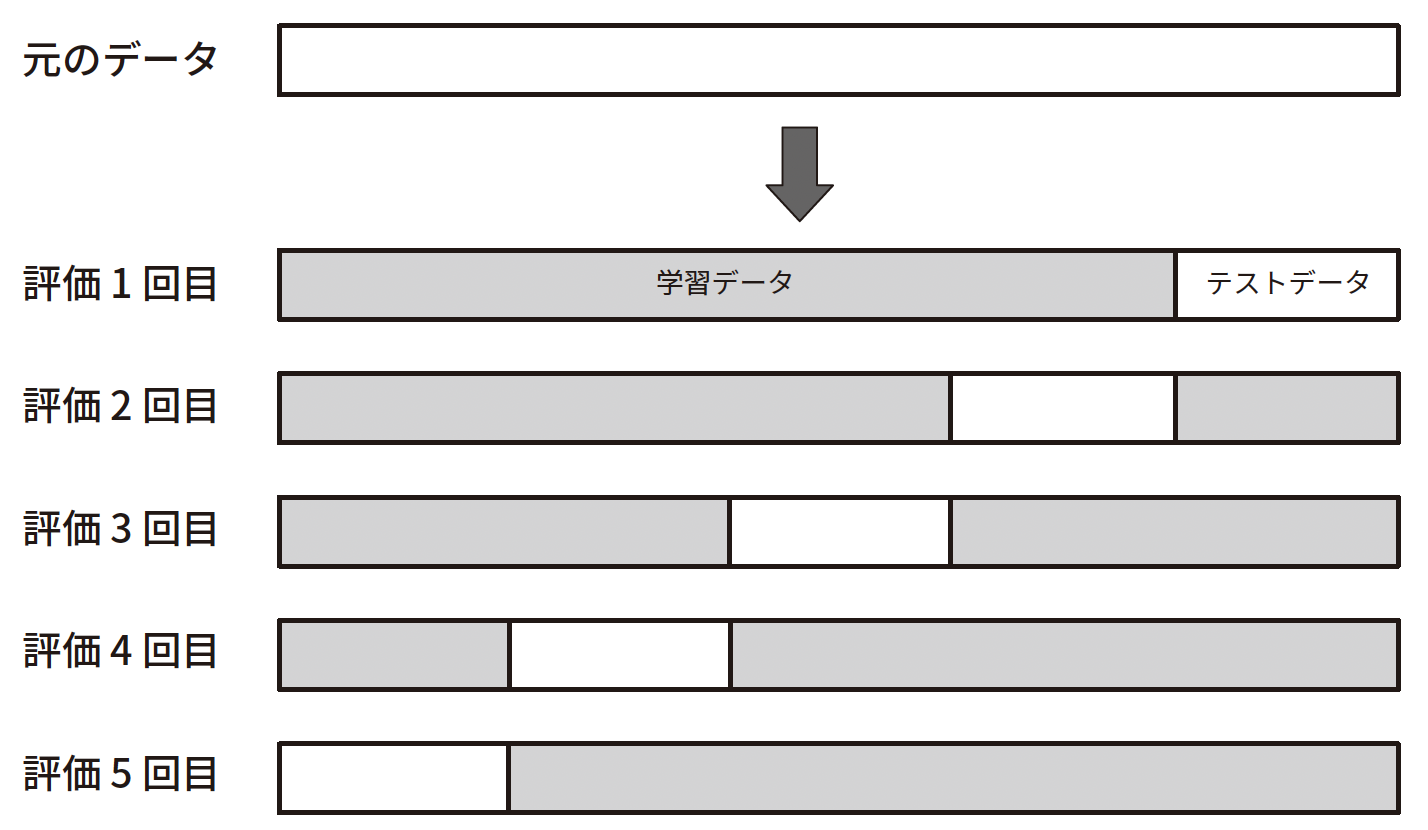

分割したおのおののグループのことを**フォールド**（fold）、データの分割数のことをフォールド数と呼びます。交差検証はすべてのデータを学習・テスト両方に効率よく利用でき、平均をとることで偶然による評価のばらつきも軽減できます。

### 交差検証の種類

上の図で挙げたように、データを単純に互い違いに$K$分割する方法をK-foldと呼びます。これ以外にも、データの特性や信頼性とスピードのバランスに応じて以下のような分割法がよく用いられます。

- K-fold
- Stratified K-fold
- LOO

それぞれ、概要と実装法を後述します。

### 交差検証の注意点

以下のような理由から、**AICやBIC、WAICを交差検証で直接求めることは、一般的には不適切**です。

- これらの指標は学習データから未知データに対する汎化性能を推定することが目的のため、未知データに対する性能を実際に計算できる交差検証では利用意義がない
- これらの指標は、学習データから求めた対数尤度の使用を前提としているため、テストデータを用いると理論的根拠が崩れる

また、データ取得時からのデータ傾向や各変数間の関係の変化、すなわちモデルドリフトが発生すると、交差検証で求めた性能であっても現在の未知データには適合しないことに注意してください。**モデルドリフトが発生した場合、モデル構築とともに交差検証による評価も再実施する必要**があります。

## 交差検証の実装

ここからは実際に交差検証による評価指標算出処理を、Pythonで実装してみます。

ここでは例として、2章で作成したサンプルデータを使用します。また教師あり・教師なし（統計モデリングも含む）どちらのパターンにも対応できるようにするため、以下の2種類のモデルの実装例をそれぞれ解説します

- A. 6章で解説した2変数のホテリング理論のモデル（教師なし学習を想定）
- B. 3章で解説したロジスティック回帰（教師あり学習を想定）

まず以下に示すように、[ch6_3_Multivariate_Hotelling.ipynb](https://github.com/ghmagazine/python_anomaly_detection_book/blob/main/notebooks/ch6_3_Multivariate_Hotelling.ipynb)で使用した学習データと、学習したモデルのパラメータを読み込みます。

In [1]:
# コード9.23 交差検証用データ読み込み
import pandas as pd

# CSVから学習用データとテストデータを読み込んで一旦合体
df_train = pd.read_csv("https://raw.githubusercontent.com/ghmagazine/python_anomaly_detection_book/refs/heads/main/notebooks/datasets/ch2_dataset_train.csv")
df_validation = pd.read_csv("https://raw.githubusercontent.com/ghmagazine/python_anomaly_detection_book/refs/heads/main/notebooks/datasets/ch2_dataset_inference.csv")
df = pd.concat([df_train, df_validation], ignore_index=True)
# "temp2","temp1"変数に欠測が含まれるデータを削除
df_dropna = df.dropna(subset=["temp2", "temp1"])
# 変数とラベルの抽出
X = df_dropna[["temp2", "temp1"]].to_numpy()
y = df_dropna["label"].to_numpy()

今回は評価指標として、F値、AU-ROC（1.ラベルの予測精度に該当）、対数尤度（2.統計モデル選択の妥当性に該当）を求めます。

「A. 2変数のホテリング理論のモデル（教師なし学習を想定）」では、F値、AU-ROC、対数尤度を計算する関数を以下のように実装します。

In [2]:
# 2変数のホテリング理論のモデルからF値、AU-ROC、対数尤度を計算する関数
import numpy as np
from scipy import stats
from sklearn.metrics import f1_score, roc_curve, auc

TARGET_FP_RATE = 0.0027 # ターゲットとする誤報率

def calculate_hotelling_metrics(X_train, X_test, y_test):
    # 正常のモデル（2次元正規分布）を学習
    mu = np.mean(X_train, axis=0) # 標本平均ベクトルμ
    Sigma = np.cov(X_train.T, ddof=0) # 標本分散共分散行列Σ
    a_th = stats.chi2.ppf(1 - TARGET_FP_RATE, df=X_train.shape[1])  # 異常度のしきい値
    # 1.ラベルの予測精度計算のためにテストデータに対する推論を実施
    X_dev = (X_test-np.array(mu)).T # テストデータと平均ベクトルとの差（x-μ）
    Sigma_inv = np.linalg.inv(np.array(Sigma)) # 標本分散共分散行列の逆行列
    Dev_Sigma = X_dev.T @ Sigma_inv # (x-μ)^T * Σ^-1
    anomaly_scores = np.sum(np.multiply(Dev_Sigma, X_dev.T), axis=1) # 異常度計算
    y_pred = np.where(anomaly_scores > a_th, 'anomaly', 'normal') # しきい値判定
    # 1.ラベルの予測精度（F値、AU-ROC）を計算
    f1 = f1_score(y_test, y_pred, pos_label='anomaly')
    fpr, tpr, _ = roc_curve(y_test, anomaly_scores, pos_label='anomaly')
    auroc = auc(fpr, tpr)
    # 2.対数尤度を計算
    first_term = np.log(2*np.pi) * len(mu)/2 # M/2log(2π)
    second_term = 0.5 * np.log(np.linalg.det(Sigma)) # 1/2 log|Σ|
    n = len(X_test) # サンプルサイズN
    log_likelihood = -n*(first_term+second_term) - 0.5*np.sum(anomaly_scores)

    return f1, auroc, log_likelihood

「B. ロジスティック回帰（教師あり学習を想定）」では、対数尤度を求めることはできないため、F値、AU-ROCを計算する関数を以下のように実装します。

In [3]:
# ロジスティック回帰モデルからF値、AU-ROCを計算する関数
from sklearn.linear_model import LogisticRegression

def calculate_logistic_regression_metrics(X_train, y_train, X_test, y_test):
    # ロジスティック回帰モデルを学習
    model = LogisticRegression(penalty=None)
    model.fit(X_train, y_train) # 学習に目的変数y_trainが必要
    # テストデータに対する推論を実施
    y_pred = model.predict(X_test)
    # ラベルの予測精度（F値、AU-ROC）を計算
    f1 = f1_score(y_test, y_pred, pos_label='anomaly')
    y_proba = model.predict_proba(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_proba[:, 0], pos_label='anomaly')
    auroc = auc(fpr, tpr)

    return f1, auroc

これらのデータと関数を用いて、各データ分割法（K-fold、Stratified K-fold、LOO）を用いた交差検証を実装していきます。

### K-fold

K-foldはデータを単純にフォールド数$K$で分割する方法です。元々のデータの順番のとおりに$K$分割することもありますが、分割の偏りを減らすために、ランダムに\frac{N}{K}個（$N$は元のデータ数）ずつデータを選ぶ方法もよく利用されます。

PythonでK-foldによる交差検証を実装するには、[sklearn.model_selection.KFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html)クラスを使用します。フォールド数$K$はインスタンス生成時の`n_splits`引数で、分割を元のデータの順番通りにするかランダムに選ぶかは`shuffle`引数で指定します。

「A. 2変数のホテリング理論のモデル（教師なし学習を想定）」での実装例を以下に示します。

In [4]:
# KFoldによる交差検証の実装（A. 2変数のホテリング理論のモデル）
from sklearn.model_selection import KFold

# K-Foldのインスタンスを作成
kf = KFold(n_splits=5, shuffle=True, random_state=42)
# 交差検証の結果（F値、AU-ROC、対数尤度）を格納するリスト
f1s = []
aurocs = []
log_likelihoods = []
# 交差検証の実行
for train_index, test_index in kf.split(X, y):
    # 学習データとテストデータに分割
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    # F値、AU-ROC、対数尤度を計算してリストに格納
    f1, auroc, log_likelihood = calculate_hotelling_metrics(
        X_train, X_test, y_test)
    f1s.append(f1)
    aurocs.append(auroc)
    log_likelihoods.append(log_likelihood)

# 交差検証の結果（5フォールドの評価指標の平均と標準偏差）を表示
print(f"F1 Score: {np.mean(f1s):.3f} ± {np.std(f1s):.3f}")
print(f"AU-ROC: {np.mean(aurocs):.3f} ± {np.std(aurocs):.3f}")
print(f"Log Likelihood: {np.mean(log_likelihoods):.3f} ± {np.std(log_likelihoods):.3f}")

F1 Score: 0.572 ± 0.181
AU-ROC: 0.987 ± 0.012
Log Likelihood: -1678.815 ± 12.846


上記の実装では、`split`メソッドを`for`でループ実行することで、分割後の学習データとテストデータのインデックスを連続的に取得することができます。

「B. ロジスティック回帰（教師あり学習を想定）」での実装例も以下に示します。

In [5]:
# KFoldによる交差検証の実装（B. ロジスティック回帰モデル）
# K-Foldのインスタンスを作成
kf = KFold(n_splits=5, shuffle=True, random_state=42)
# 交差検証の結果（F値、AU-ROC、対数尤度）を格納するリスト
f1s = []
aurocs = []
log_likelihoods = []
# 交差検証の実行
for train_index, test_index in kf.split(X, y):
    # 学習データとテストデータに分割
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    # F値、AU-ROC、対数尤度を計算してリストに格納
    f1, auroc = calculate_logistic_regression_metrics(
        X_train, y_train, X_test, y_test)
    f1s.append(f1)
    aurocs.append(auroc)
    log_likelihoods.append(log_likelihood)

# 交差検証の結果（5フォールドの評価指標の平均と標準偏差）を表示
print(f"F1 Score: {np.mean(f1s):.3f} ± {np.std(f1s):.3f}")
print(f"AU-ROC: {np.mean(aurocs):.3f} ± {np.std(aurocs):.3f}")

F1 Score: 0.849 ± 0.128
AU-ROC: 0.998 ± 0.001


### Stratified K-fold

**Stratified K-fold**は以下の図に示すように、各フォールド内のクラス比率（正常／異常の割合）を元データと同じに保つようデータを分割する方法です。

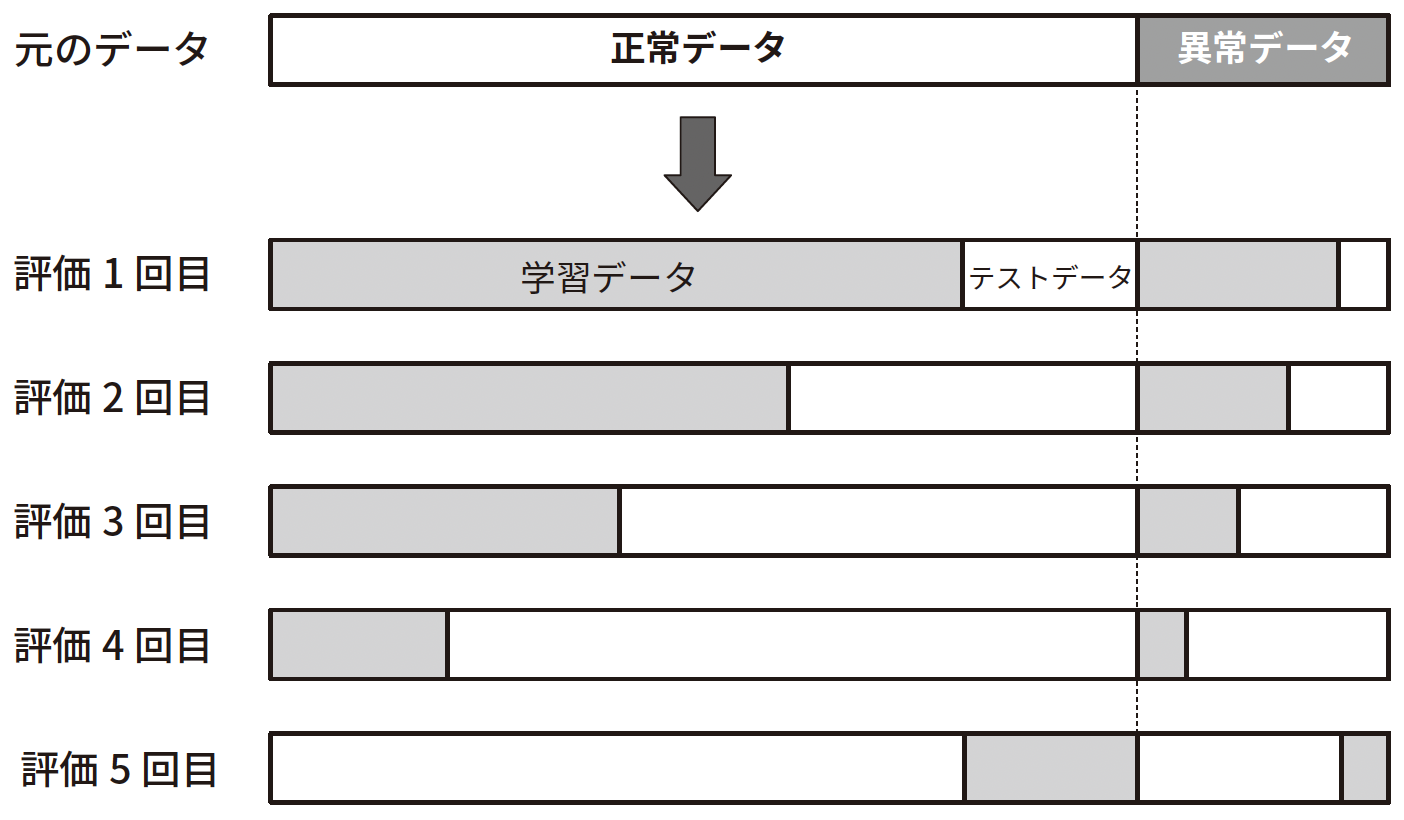

異常検知では、正常データと比べて異常データが極端に少ない不均衡データが頻繁に発生するため、単純なK-foldでは異常データが1個も含まれないフォールドが生じる可能性もあります。Stratified K-foldは異常データの割合を一定に保ちながら分割できるため、不均衡データを安定して評価できる、**異常検知に適したデータ分割法**と言えます。

PythonでStratified K-foldによる交差検証を実装するには、[sklearn.model_selection.StratifiedKFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html)クラスを使用します。

「A. 2変数のホテリング理論のモデル（教師なし学習を想定）」での実装例を以下に示します。

In [6]:
# コード9.24 Stratified K-Foldによる交差検証の実装（A. 2変数のホテリング理論のモデル）
from sklearn.model_selection import StratifiedKFold

# Stratified K-Foldのインスタンスを作成
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# 交差検証の結果（F値、AU-ROC、対数尤度）を格納するリスト
f1s = []
aurocs = []
log_likelihoods = []
# 交差検証の実行
for train_index, test_index in skf.split(X, y):
    # 学習データとテストデータに分割
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    # F値、AU-ROC、対数尤度を計算してリストに格納
    f1, auroc, log_likelihood = calculate_hotelling_metrics(
        X_train, X_test, y_test)
    f1s.append(f1)
    aurocs.append(auroc)
    log_likelihoods.append(log_likelihood)

# 交差検証の結果（5フォールドの評価指標の平均と標準偏差）を表示
print(f"F1 Score: {np.mean(f1s):.3f} ± {np.std(f1s):.3f}")
print(f"AU-ROC: {np.mean(aurocs):.3f} ± {np.std(aurocs):.3f}")
print(f"Log Likelihood: {np.mean(log_likelihoods):.3f} ± {np.std(log_likelihoods):.3f}")

F1 Score: 0.668 ± 0.135
AU-ROC: 0.986 ± 0.017
Log Likelihood: -1678.124 ± 10.631


`split`メソッド実行時に第二引数`y`（目的変数データ）のクラス比率が元データと等しくなるように、連続的にデータが分割されます。

「B. ロジスティック回帰（教師あり学習を想定）」での実装例も以下に示します。

In [7]:
# Stratified K-Foldによる交差検証の実装（B. ロジスティック回帰モデル）
# Stratified K-Foldのインスタンスを作成
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# 交差検証の結果（F値、AU-ROC、対数尤度）を格納するリスト
f1s = []
aurocs = []
log_likelihoods = []
# 交差検証の実行
for train_index, test_index in skf.split(X, y):
    # 学習データとテストデータに分割
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    # F値、AU-ROC、対数尤度を計算してリストに格納
    f1, auroc = calculate_logistic_regression_metrics(
        X_train, y_train, X_test, y_test)
    f1s.append(f1)
    aurocs.append(auroc)
    log_likelihoods.append(log_likelihood)

# 交差検証の結果（5フォールドの評価指標の平均と標準偏差）を表示
print(f"F1 Score: {np.mean(f1s):.3f} ± {np.std(f1s):.3f}")
print(f"AU-ROC: {np.mean(aurocs):.3f} ± {np.std(aurocs):.3f}")

F1 Score: 0.878 ± 0.128
AU-ROC: 0.998 ± 0.003


先ほどのK-Foldの例でもそうでしたが、ロジスティック回帰モデル（教師あり学習モデル）を使用したケースの方が、ホテリング理論（教師なし学習モデル）よりも分類スコア（F値やAU-ROC）が良くなっています。これは教師あり学習モデル（分類）は異常と正常の判別性能（分類性能）を上げるようにモデルの学習が進むのに対し、教師なし学習は正常時誤報率を一定に保つようにモデルを構築しており、分類性能の向上を学習の目的としていないからです。

このように正常と異常の判別性能という観点では、盲目的に教師なし学習を選択することが最良ではないことがデータでも確認できました。判別性能の向上のためには、多少無理をしてでも異常データを多く取得し教師あり学習を採用することを検討しても良いでしょう。

### LOO

**LOO**（Leave One Out：1個抜き交差検証）は以下の図に示すように、テストデータを1個選択し、残りをすべて学習データとした評価を$N$フォールド繰り返す方法です。

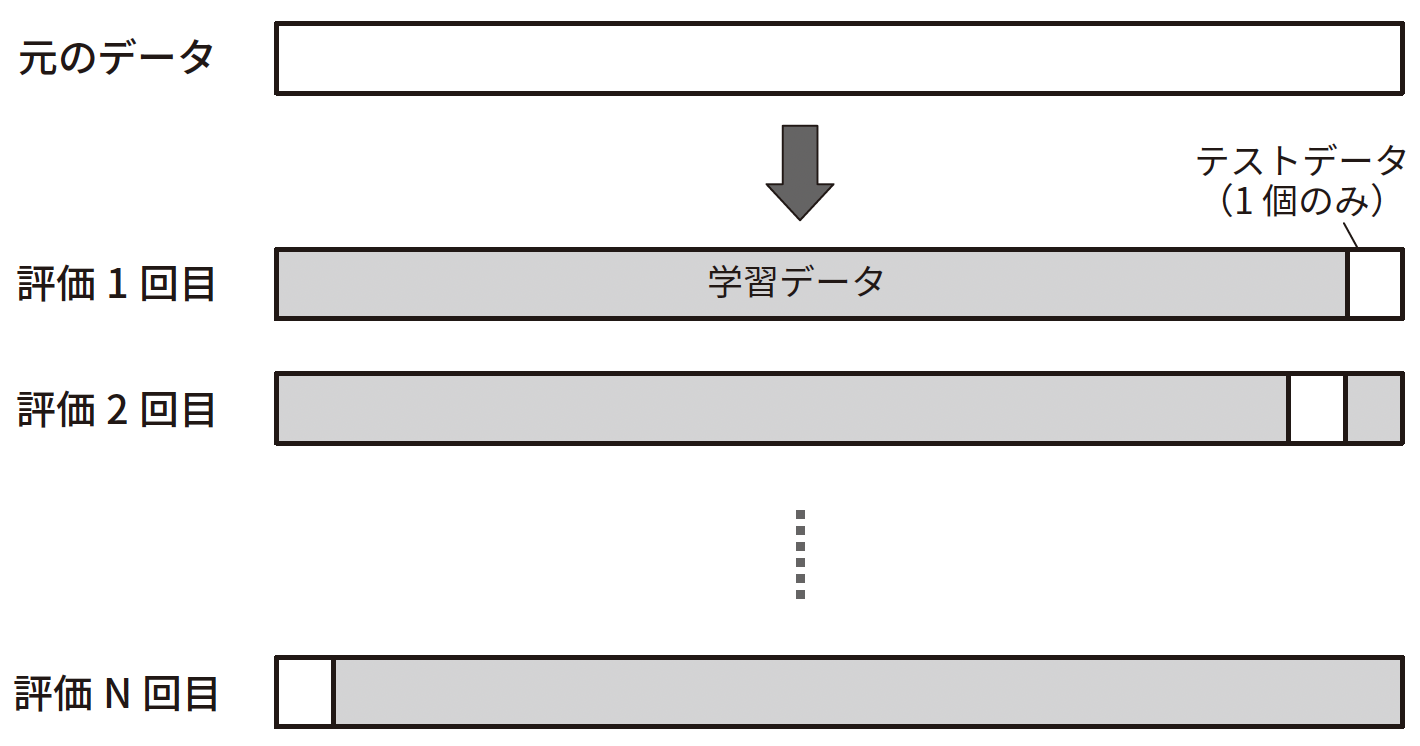

LOOはテストデータが1個しかないため、指標の算出に異常・正常データ両方を必要とする「1. ラベルの予測精度の評価」での実用性は低く、もう片方の「2. 統計モデル選択の妥当性の評価」に関して、未知データの対数尤度を求める目的で利用されます。しかしながらフォールド数が多いLOOによる対数尤度の計算は、計算負荷が高いことが難点であるため、データ数が多い場合は実際にデータを分割した指標計算が困難なケースも多いでしょう。このような場合は、PSIS（Pareto-smoothed importance sampling：パレート平滑化重要度サンプリング）等の近似計算法が用いられます。

PythonでLOOによる交差検証（近似計算法ではなく実際にデータを分割した指標計算）を実装するには、[sklearn.model_selection.LeaveOneOut](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.LeaveOneOut.html)クラスを使用します。

「A. 2変数のホテリング理論のモデル（教師なし学習を想定）」において、対数尤度をLOOで計算する実装例を以下に示します。

In [8]:
# LOOによる交差検証の実装（A. 2変数のホテリング理論のモデル）
from sklearn.model_selection import LeaveOneOut

def calculate_hotelling_loglikelihood(X_train, X_test):
    """2変数のホテリング理論のモデルから対数尤度を計算する関数"""
    # 正常のモデル（2次元正規分布）を学習
    mu = np.mean(X_train, axis=0) # 標本平均ベクトルμ
    Sigma = np.cov(X_train.T, ddof=0) # 標本分散共分散行列Σ
    # 対数尤度を計算
    X_dev = (X_test-np.array(mu)).T # テストデータと平均ベクトルとの差（x-μ）
    Sigma_inv = np.linalg.inv(np.array(Sigma)) # 標本分散共分散行列の逆行列
    Dev_Sigma = X_dev.T @ Sigma_inv # (x-μ)^T * Σ^-1
    anomaly_scores = np.sum(np.multiply(Dev_Sigma, X_dev.T), axis=1) # 異常度計算
    first_term = np.log(2*np.pi) * len(mu)/2 # M/2log(2π)
    second_term = 0.5 * np.log(np.linalg.det(Sigma)) # 1/2 log|Σ|
    n = len(X_test) # サンプルサイズN
    log_likelihood = -n*(first_term+second_term) - 0.5*np.sum(anomaly_scores)

    return log_likelihood

# LOOのインスタンスを作成
loo = LeaveOneOut()
# 交差検証の結果（対数尤度）を格納するリスト
log_likelihoods = []
# 交差検証の実行
for train_index, test_index in loo.split(X):
    # 学習データとテストデータに分割
    X_train, X_test = X[train_index], X[test_index]
    # F値、AU-ROC、対数尤度を計算してリストに格納
    log_likelihood = calculate_hotelling_loglikelihood(
        X_train, X_test)
    log_likelihoods.append(log_likelihood)

# 交差検証の結果（Nフォールドの評価指標の平均と標準偏差）を表示
print(f"n_fold = {len(log_likelihoods)}")
print(f"Log Likelihood: {np.mean(log_likelihoods):.3f} ± {np.std(log_likelihoods):.3f}")

n_fold = 1392
Log Likelihood: -6.029 ± 1.297


「B. ロジスティック回帰（教師あり学習を想定）」では対数尤度を計算できないため、異常検知においてLOOを採用することは基本的にはないでしょう。